# 1. Project Title: SentimentScope - Model Comparison

This notebook performs a comprehensive evaluation and comparison of five machine learning models trained on the balanced product review dataset.

## 2. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import os
import sys
import time
import matplotlib.pyplot as plt

sys.path.append("../src")
from text_normalizer import clean_text
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import LabelEncoder, label_binarize

# Machine Learning Algorithms
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier


## 3. Load Dataset

In [2]:
CSV_PATH = "../data/balanced_reviews.csv"

print("Loading balanced dataset...")
df = pd.read_csv(CSV_PATH)
print(f"Dataset Shape: {df.shape}")

Loading balanced dataset...
Dataset Shape: (26400, 6)


## 4. Data Cleaning

In [3]:
print("Dropping null values from text and sentiment columns...")
df = df.dropna(subset=['review_text', 'sentiment'])
print(f"Shape after null removal: {df.shape}")

print("\nNormalizing review texts using clean_text()...")
df['clean_review'] = df['review_text'].astype(str).apply(clean_text)
print("Sample cleaned review:")
print(df['clean_review'].iloc[0])

Dropping null values from text and sentiment columns...
Shape after null removal: (26400, 6)

Normalizing review texts using clean_text()...
Sample cleaned review:
great product provide good support while heavy lifting


## 5. Train/Test Split

In [4]:
print("Splitting dataset (80% train, 20% test)...")
X = df['clean_review']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20,
    random_state=42,
    stratify=y
)
print(f"Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")

Splitting dataset (80% train, 20% test)...
Train size: 21120 | Test size: 5280


## 6. TF-IDF Vectorization

In [5]:
print("Fitting TF-IDF Vectorizer only once on train, and transforming test...")
vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=15000, stop_words="english")
X_train_vectorized = vectorizer.fit_transform(X_train)
X_test_vectorized = vectorizer.transform(X_test)
print(f"TF-IDF Feature Space Size: {X_train_vectorized.shape[1]} features")

# Prepare label binarizer for multiclass ROC-AUC calculation
classes = ["Negative", "Neutral", "Positive"]
y_test_binarized = label_binarize(y_test, classes=classes)

# Dictionary to store results for comparison
results = {}

Fitting TF-IDF Vectorizer only once on train, and transforming test...
TF-IDF Feature Space Size: 15000 features


## 7. Train Linear SVM

In [6]:
print("Training Linear SVM...")
svm_model = LinearSVC(random_state=42, max_iter=1000)

start_time = time.time()
svm_model.fit(X_train_vectorized, y_train)
train_time = time.time() - start_time

start_time = time.time()
y_pred = svm_model.predict(X_test_vectorized)
pred_time = time.time() - start_time

# 5-Fold Cross Validation
print("Performing 5-Fold Cross Validation...")
cv_scores = cross_val_score(svm_model, X_train_vectorized, y_train, cv=5, scoring="accuracy")
mean_cv = cv_scores.mean()
std_cv = cv_scores.std()

print("--------------------------------------------------")
print("Linear SVM")
for i, score in enumerate(cv_scores):
    print(f"Fold {i+1} : {score * 100:.2f}%")
print(f"Average Accuracy : {mean_cv * 100:.2f}%")
print(f"Std Dev : {std_cv * 100:.2f}%")
print("--------------------------------------------------")

# ROC-AUC Score
y_prob = svm_model.decision_function(X_test_vectorized)
roc_auc = roc_auc_score(y_test_binarized, y_prob, multi_class="ovr", average="macro")

accuracy = accuracy_score(y_test, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')

results["Linear SVM"] = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1,
    "ROC-AUC": roc_auc,
    "CV Accuracy": mean_cv,
    "Training Time (sec)": train_time,
    "Prediction Time (sec)": pred_time
}

print(f"Accuracy: {accuracy:.4f} | ROC-AUC: {roc_auc:.4f} | CV Accuracy: {mean_cv:.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred, labels=["Negative", "Neutral", "Positive"]))

Training Linear SVM...
Performing 5-Fold Cross Validation...
--------------------------------------------------
Linear SVM
Fold 1 : 76.92%
Fold 2 : 77.13%
Fold 3 : 77.34%
Fold 4 : 77.77%
Fold 5 : 76.87%
Average Accuracy : 77.21%
Std Dev : 0.33%
--------------------------------------------------
Accuracy: 0.7684 | ROC-AUC: 0.9025 | CV Accuracy: 0.7721

Classification Report:
              precision    recall  f1-score   support

    Negative       0.77      0.76      0.76      1760
     Neutral       0.74      0.72      0.73      1760
    Positive       0.79      0.83      0.81      1760

    accuracy                           0.77      5280
   macro avg       0.77      0.77      0.77      5280
weighted avg       0.77      0.77      0.77      5280

Confusion Matrix:
[[1330  253  177]
 [ 290 1260  210]
 [ 112  181 1467]]


## 8. Train Logistic Regression

In [7]:
print("Training Logistic Regression...")
lr_model = LogisticRegression(max_iter=1000, random_state=42)

start_time = time.time()
lr_model.fit(X_train_vectorized, y_train)
train_time = time.time() - start_time

start_time = time.time()
y_pred = lr_model.predict(X_test_vectorized)
pred_time = time.time() - start_time

# 5-Fold Cross Validation
print("Performing 5-Fold Cross Validation...")
cv_scores = cross_val_score(lr_model, X_train_vectorized, y_train, cv=5, scoring="accuracy")
mean_cv = cv_scores.mean()
std_cv = cv_scores.std()

print("--------------------------------------------------")
print("Logistic Regression")
for i, score in enumerate(cv_scores):
    print(f"Fold {i+1} : {score * 100:.2f}%")
print(f"Average Accuracy : {mean_cv * 100:.2f}%")
print(f"Std Dev : {std_cv * 100:.2f}%")
print("--------------------------------------------------")

# ROC-AUC Score
y_prob = lr_model.predict_proba(X_test_vectorized)
roc_auc = roc_auc_score(y_test_binarized, y_prob, multi_class="ovr", average="macro")

accuracy = accuracy_score(y_test, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')

results["Logistic Regression"] = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1,
    "ROC-AUC": roc_auc,
    "CV Accuracy": mean_cv,
    "Training Time (sec)": train_time,
    "Prediction Time (sec)": pred_time
}

print(f"Accuracy: {accuracy:.4f} | ROC-AUC: {roc_auc:.4f} | CV Accuracy: {mean_cv:.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred, labels=["Negative", "Neutral", "Positive"]))

Training Logistic Regression...
Performing 5-Fold Cross Validation...
--------------------------------------------------
Logistic Regression
Fold 1 : 77.94%
Fold 2 : 78.46%
Fold 3 : 78.91%
Fold 4 : 79.12%
Fold 5 : 78.29%
Average Accuracy : 78.54%
Std Dev : 0.43%
--------------------------------------------------
Accuracy: 0.7752 | ROC-AUC: 0.9146 | CV Accuracy: 0.7854

Classification Report:
              precision    recall  f1-score   support

    Negative       0.77      0.77      0.77      1760
     Neutral       0.75      0.72      0.74      1760
    Positive       0.80      0.84      0.82      1760

    accuracy                           0.78      5280
   macro avg       0.77      0.78      0.77      5280
weighted avg       0.77      0.78      0.77      5280

Confusion Matrix:
[[1355  246  159]
 [ 294 1263  203]
 [ 121  164 1475]]


## 9. Train Multinomial Naive Bayes

In [8]:
print("Training Multinomial Naive Bayes...")
nb_model = MultinomialNB()

start_time = time.time()
nb_model.fit(X_train_vectorized, y_train)
train_time = time.time() - start_time

start_time = time.time()
y_pred = nb_model.predict(X_test_vectorized)
pred_time = time.time() - start_time

# 5-Fold Cross Validation
print("Performing 5-Fold Cross Validation...")
cv_scores = cross_val_score(nb_model, X_train_vectorized, y_train, cv=5, scoring="accuracy")
mean_cv = cv_scores.mean()
std_cv = cv_scores.std()

print("--------------------------------------------------")
print("Multinomial Naive Bayes")
for i, score in enumerate(cv_scores):
    print(f"Fold {i+1} : {score * 100:.2f}%")
print(f"Average Accuracy : {mean_cv * 100:.2f}%")
print(f"Std Dev : {std_cv * 100:.2f}%")
print("--------------------------------------------------")

# ROC-AUC Score
y_prob = nb_model.predict_proba(X_test_vectorized)
roc_auc = roc_auc_score(y_test_binarized, y_prob, multi_class="ovr", average="macro")

accuracy = accuracy_score(y_test, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')

results["Multinomial Naive Bayes"] = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1,
    "ROC-AUC": roc_auc,
    "CV Accuracy": mean_cv,
    "Training Time (sec)": train_time,
    "Prediction Time (sec)": pred_time
}

print(f"Accuracy: {accuracy:.4f} | ROC-AUC: {roc_auc:.4f} | CV Accuracy: {mean_cv:.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred, labels=["Negative", "Neutral", "Positive"]))

Training Multinomial Naive Bayes...
Performing 5-Fold Cross Validation...
--------------------------------------------------
Multinomial Naive Bayes
Fold 1 : 76.25%
Fold 2 : 77.04%
Fold 3 : 76.66%
Fold 4 : 78.27%
Fold 5 : 76.35%
Average Accuracy : 76.91%
Std Dev : 0.73%
--------------------------------------------------
Accuracy: 0.7561 | ROC-AUC: 0.9108 | CV Accuracy: 0.7691

Classification Report:
              precision    recall  f1-score   support

    Negative       0.71      0.79      0.75      1760
     Neutral       0.80      0.62      0.70      1760
    Positive       0.77      0.86      0.81      1760

    accuracy                           0.76      5280
   macro avg       0.76      0.76      0.75      5280
weighted avg       0.76      0.76      0.75      5280

Confusion Matrix:
[[1391  173  196]
 [ 420 1094  246]
 [ 144  109 1507]]


## 10. Train Random Forest

In [9]:
print("Training Random Forest (this may take a few minutes)...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

start_time = time.time()
rf_model.fit(X_train_vectorized, y_train)
train_time = time.time() - start_time

start_time = time.time()
y_pred = rf_model.predict(X_test_vectorized)
pred_time = time.time() - start_time

# 5-Fold Cross Validation
print("Performing 5-Fold Cross Validation...")
cv_scores = cross_val_score(rf_model, X_train_vectorized, y_train, cv=5, scoring="accuracy")
mean_cv = cv_scores.mean()
std_cv = cv_scores.std()

print("--------------------------------------------------")
print("Random Forest")
for i, score in enumerate(cv_scores):
    print(f"Fold {i+1} : {score * 100:.2f}%")
print(f"Average Accuracy : {mean_cv * 100:.2f}%")
print(f"Std Dev : {std_cv * 100:.2f}%")
print("--------------------------------------------------")

# ROC-AUC Score
y_prob = rf_model.predict_proba(X_test_vectorized)
roc_auc = roc_auc_score(y_test_binarized, y_prob, multi_class="ovr", average="macro")

accuracy = accuracy_score(y_test, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')

results["Random Forest"] = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1,
    "ROC-AUC": roc_auc,
    "CV Accuracy": mean_cv,
    "Training Time (sec)": train_time,
    "Prediction Time (sec)": pred_time
}

print(f"Accuracy: {accuracy:.4f} | ROC-AUC: {roc_auc:.4f} | CV Accuracy: {mean_cv:.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred, labels=["Negative", "Neutral", "Positive"]))

Training Random Forest (this may take a few minutes)...
Performing 5-Fold Cross Validation...
--------------------------------------------------
Random Forest
Fold 1 : 77.98%
Fold 2 : 78.41%
Fold 3 : 79.10%
Fold 4 : 78.88%
Fold 5 : 77.94%
Average Accuracy : 78.46%
Std Dev : 0.47%
--------------------------------------------------
Accuracy: 0.7765 | ROC-AUC: 0.9133 | CV Accuracy: 0.7846

Classification Report:
              precision    recall  f1-score   support

    Negative       0.79      0.74      0.76      1760
     Neutral       0.77      0.73      0.75      1760
    Positive       0.77      0.86      0.81      1760

    accuracy                           0.78      5280
   macro avg       0.78      0.78      0.78      5280
weighted avg       0.78      0.78      0.78      5280

Confusion Matrix:
[[1300  249  211]
 [ 242 1285  233]
 [ 105  140 1515]]


## 11. Train XGBoost

In [10]:
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

try:
    import xgboost as xgb
    from xgboost import XGBClassifier
    print("XGBoost library found. Training XGBClassifier...")
    xgb_model = XGBClassifier(n_estimators=100, random_state=42, n_jobs=-1, eval_metric='mlogloss')
    
    start_time = time.time()
    xgb_model.fit(X_train_vectorized, y_train_encoded)
    train_time = time.time() - start_time
    
    start_time = time.time()
    y_pred_encoded = xgb_model.predict(X_test_vectorized)
    pred_time = time.time() - start_time
    y_pred = label_encoder.inverse_transform(y_pred_encoded)
    
    # 5-Fold Cross Validation
    print("Performing 5-Fold Cross Validation...")
    cv_scores = cross_val_score(xgb_model, X_train_vectorized, y_train_encoded, cv=5, scoring="accuracy")
    mean_cv = cv_scores.mean()
    std_cv = cv_scores.std()
    
    # ROC-AUC Score
    y_prob = xgb_model.predict_proba(X_test_vectorized)
    roc_auc = roc_auc_score(y_test_binarized, y_prob, multi_class="ovr", average="macro")
    model_used = "XGBoost"
except ImportError:
    from sklearn.ensemble import GradientBoostingClassifier
    print("XGBoost not available. Falling back to GradientBoostingClassifier...")
    gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
    
    start_time = time.time()
    gb_model.fit(X_train_vectorized, y_train_encoded)
    train_time = time.time() - start_time
    
    start_time = time.time()
    y_pred_encoded = gb_model.predict(X_test_vectorized)
    pred_time = time.time() - start_time
    y_pred = label_encoder.inverse_transform(y_pred_encoded)
    
    # 5-Fold Cross Validation
    print("Performing 5-Fold Cross Validation...")
    cv_scores = cross_val_score(gb_model, X_train_vectorized, y_train_encoded, cv=5, scoring="accuracy")
    mean_cv = cv_scores.mean()
    std_cv = cv_scores.std()
    
    # ROC-AUC Score
    y_prob = gb_model.predict_proba(X_test_vectorized)
    roc_auc = roc_auc_score(y_test_binarized, y_prob, multi_class="ovr", average="macro")
    model_used = "XGBoost (GradientBoosting Fallback)"

print("--------------------------------------------------")
print("XGBoost")
for i, score in enumerate(cv_scores):
    print(f"Fold {i+1} : {score * 100:.2f}%")
print(f"Average Accuracy : {mean_cv * 100:.2f}%")
print(f"Std Dev : {std_cv * 100:.2f}%")
print("--------------------------------------------------")

accuracy = accuracy_score(y_test, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')

results["XGBoost"] = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1,
    "ROC-AUC": roc_auc,
    "CV Accuracy": mean_cv,
    "Training Time (sec)": train_time,
    "Prediction Time (sec)": pred_time
}

print(f"Algorithm: {model_used}")
print(f"Accuracy: {accuracy:.4f} | ROC-AUC: {roc_auc:.4f} | CV Accuracy: {mean_cv:.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred, labels=["Negative", "Neutral", "Positive"]))

XGBoost not available. Falling back to GradientBoostingClassifier...
Performing 5-Fold Cross Validation...
--------------------------------------------------
XGBoost
Fold 1 : 75.85%
Fold 2 : 75.92%
Fold 3 : 76.78%
Fold 4 : 75.97%
Fold 5 : 75.36%
Average Accuracy : 75.98%
Std Dev : 0.46%
--------------------------------------------------
Algorithm: XGBoost (GradientBoosting Fallback)
Accuracy: 0.7553 | ROC-AUC: 0.8987 | CV Accuracy: 0.7598

Classification Report:
              precision    recall  f1-score   support

    Negative       0.82      0.65      0.73      1760
     Neutral       0.69      0.79      0.74      1760
    Positive       0.77      0.82      0.80      1760

    accuracy                           0.76      5280
   macro avg       0.76      0.76      0.75      5280
weighted avg       0.76      0.76      0.75      5280

Confusion Matrix:
[[1145  401  214]
 [ 156 1393  211]
 [  95  215 1450]]


## 12. Performance Comparison

In [11]:
comparison_data = []
for model_name, metrics in results.items():
    comparison_data.append({
        "Model": model_name,
        "Accuracy": metrics["Accuracy"],
        "Precision": metrics["Precision"],
        "Recall": metrics["Recall"],
        "F1 Score": metrics["F1 Score"],
        "ROC-AUC": metrics["ROC-AUC"],
        "CV Accuracy": metrics["CV Accuracy"],
        "Training Time (sec)": metrics["Training Time (sec)"],
        "Prediction Time (sec)": metrics["Prediction Time (sec)"]
    })

comparison_df = pd.DataFrame(comparison_data)
# Sort descending by Accuracy
comparison_df = comparison_df.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)
comparison_df.insert(0, "Rank", range(1, len(comparison_df) + 1))

print("==================================================")
print("MODEL PERFORMANCE COMPARISON (RANKED)")
print("==================================================")
print(comparison_df.to_string(index=False))

# Export comparison results
REPORTS_DIR = "../reports"
os.makedirs(REPORTS_DIR, exist_ok=True)
csv_export_path = os.path.join(REPORTS_DIR, "model_comparison.csv")
xlsx_export_path = os.path.join(REPORTS_DIR, "model_comparison.xlsx")

comparison_df.to_csv(csv_export_path, index=False)
comparison_df.to_excel(xlsx_export_path, index=False)

print(f"\nSuccessfully exported comparison table to:")
print(f" - CSV: {csv_export_path}")
print(f" - Excel: {xlsx_export_path}")

MODEL PERFORMANCE COMPARISON (RANKED)
 Rank                   Model  Accuracy  Precision   Recall  F1 Score  ROC-AUC  CV Accuracy  Training Time (sec)  Prediction Time (sec)
    1           Random Forest  0.776515   0.776763 0.776515  0.775423 0.913305     0.784612             8.293674               0.087959
    2     Logistic Regression  0.775189   0.774469 0.775189  0.774544 0.914624     0.785417             1.151597               0.003372
    3              Linear SVM  0.768371   0.767654 0.768371  0.767724 0.902522     0.772064             4.064868               0.000000
    4 Multinomial Naive Bayes  0.756061   0.759928 0.756061  0.753059 0.910811     0.769129             0.046484               0.000984
    5                 XGBoost  0.755303   0.762305 0.755303  0.754196 0.898720     0.759754            19.853741               0.014695

Successfully exported comparison table to:
 - CSV: ../reports\model_comparison.csv
 - Excel: ../reports\model_comparison.xlsx


## 13. Visual Comparison

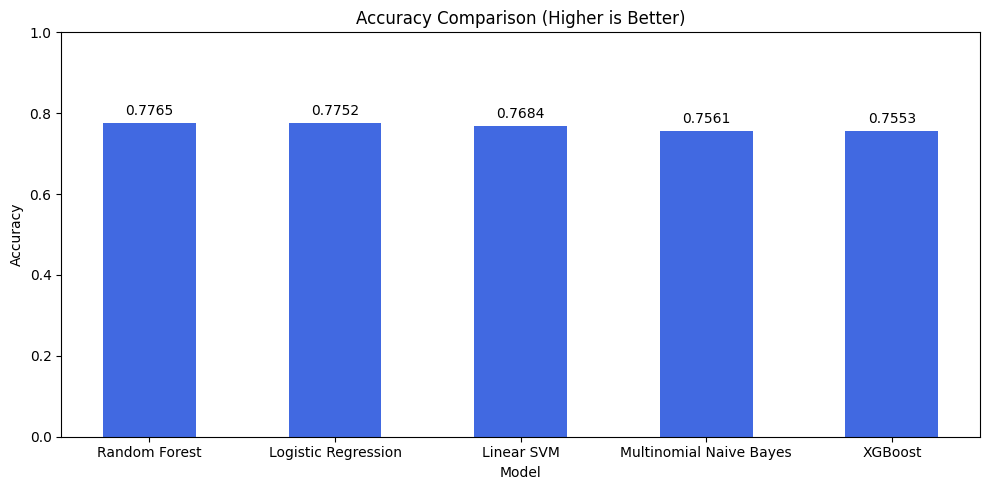

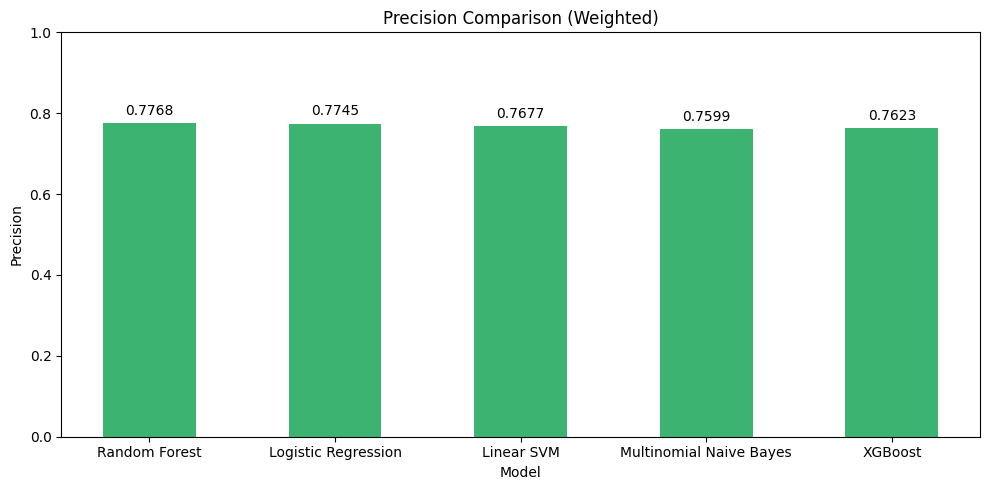

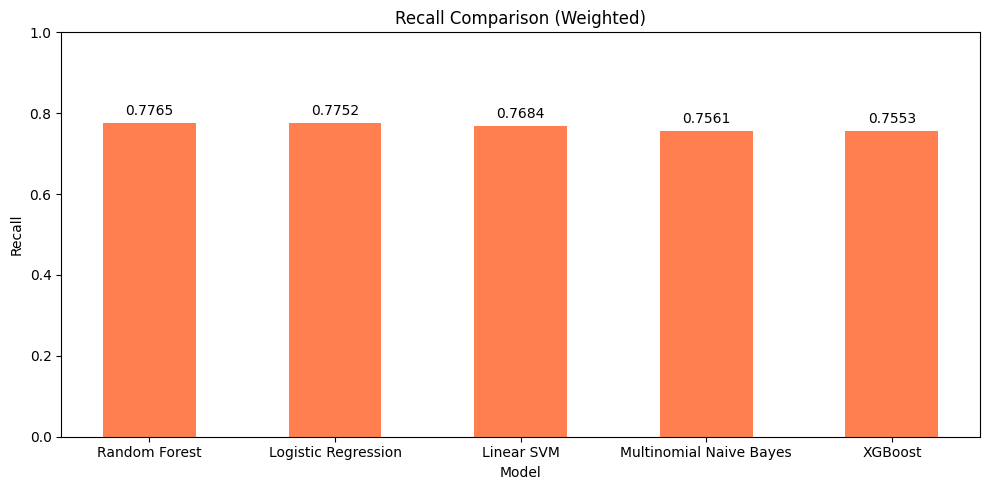

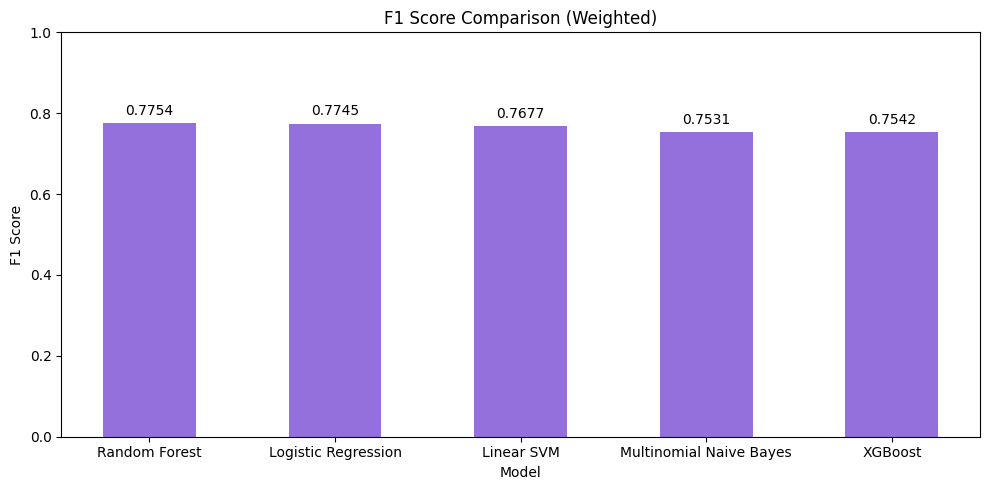

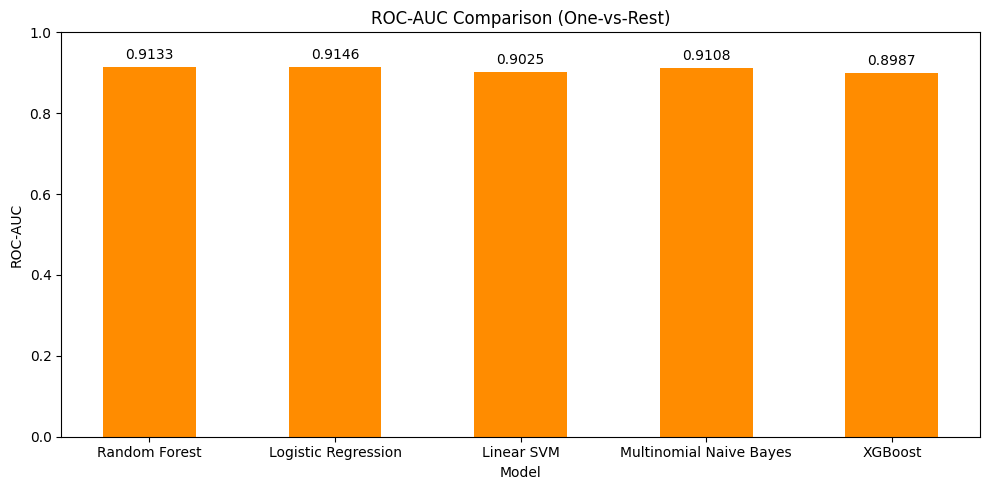

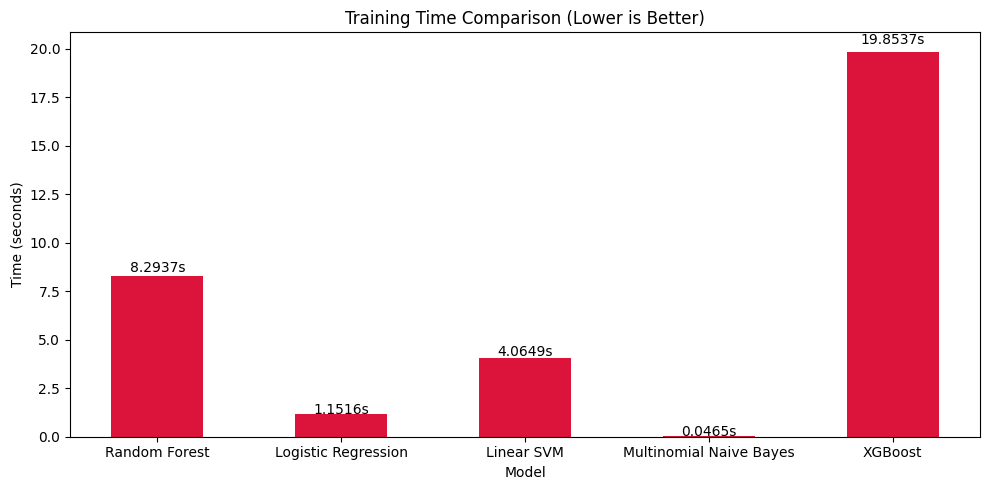

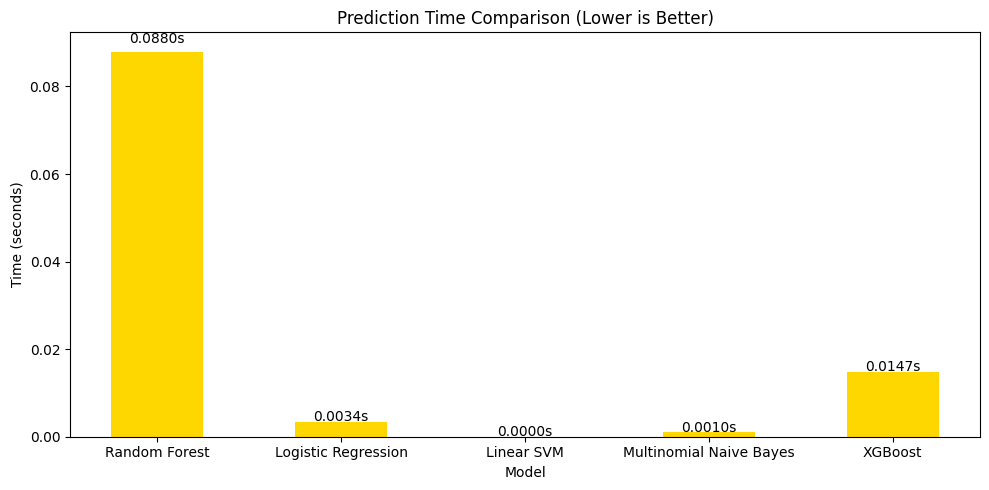

In [12]:
models = comparison_df['Model'].tolist()
os.makedirs("../reports", exist_ok=True)

# 1. Accuracy Comparison
plt.figure(figsize=(10, 5))
plt.bar(models, comparison_df['Accuracy'], color='royalblue', width=0.5)
plt.title('Accuracy Comparison (Higher is Better)')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0, 1.0)
for idx, val in enumerate(comparison_df['Accuracy']):
    plt.text(idx, val + 0.02, f"{val:.4f}", ha='center')
plt.tight_layout()
plt.savefig("../reports/accuracy_comparison.png")
plt.show()

# 2. Precision Comparison
plt.figure(figsize=(10, 5))
plt.bar(models, comparison_df['Precision'], color='mediumseagreen', width=0.5)
plt.title('Precision Comparison (Weighted)')
plt.xlabel('Model')
plt.ylabel('Precision')
plt.ylim(0, 1.0)
for idx, val in enumerate(comparison_df['Precision']):
    plt.text(idx, val + 0.02, f"{val:.4f}", ha='center')
plt.tight_layout()
plt.savefig("../reports/precision_comparison.png")
plt.show()

# 3. Recall Comparison
plt.figure(figsize=(10, 5))
plt.bar(models, comparison_df['Recall'], color='coral', width=0.5)
plt.title('Recall Comparison (Weighted)')
plt.xlabel('Model')
plt.ylabel('Recall')
plt.ylim(0, 1.0)
for idx, val in enumerate(comparison_df['Recall']):
    plt.text(idx, val + 0.02, f"{val:.4f}", ha='center')
plt.tight_layout()
plt.savefig("../reports/recall_comparison.png")
plt.show()

# 4. F1 Score Comparison
plt.figure(figsize=(10, 5))
plt.bar(models, comparison_df['F1 Score'], color='mediumpurple', width=0.5)
plt.title('F1 Score Comparison (Weighted)')
plt.xlabel('Model')
plt.ylabel('F1 Score')
plt.ylim(0, 1.0)
for idx, val in enumerate(comparison_df['F1 Score']):
    plt.text(idx, val + 0.02, f"{val:.4f}", ha='center')
plt.tight_layout()
plt.savefig("../reports/f1_comparison.png")
plt.show()

# 5. ROC-AUC Comparison
plt.figure(figsize=(10, 5))
plt.bar(models, comparison_df['ROC-AUC'], color='darkorange', width=0.5)
plt.title('ROC-AUC Comparison (One-vs-Rest)')
plt.xlabel('Model')
plt.ylabel('ROC-AUC')
plt.ylim(0, 1.0)
for idx, val in enumerate(comparison_df['ROC-AUC']):
    plt.text(idx, val + 0.02, f"{val:.4f}", ha='center')
plt.tight_layout()
plt.savefig("../reports/roc_auc_comparison.png")
plt.show()

# 6. Training Time Comparison
plt.figure(figsize=(10, 5))
plt.bar(models, comparison_df['Training Time (sec)'], color='crimson', width=0.5)
plt.title('Training Time Comparison (Lower is Better)')
plt.xlabel('Model')
plt.ylabel('Time (seconds)')
for idx, val in enumerate(comparison_df['Training Time (sec)']):
    plt.text(idx, val + (val * 0.02) + 0.01, f"{val:.4f}s", ha='center')
plt.tight_layout()
plt.savefig("../reports/training_time_comparison.png")
plt.show()

# 7. Prediction Time Comparison
plt.figure(figsize=(10, 5))
plt.bar(models, comparison_df['Prediction Time (sec)'], color='gold', width=0.5)
plt.title('Prediction Time Comparison (Lower is Better)')
plt.xlabel('Model')
plt.ylabel('Time (seconds)')
for idx, val in enumerate(comparison_df['Prediction Time (sec)']):
    plt.text(idx, val + (val * 0.02) + 0.0001, f"{val:.4f}s", ha='center')
plt.tight_layout()
plt.savefig("../reports/prediction_time_comparison.png")
plt.show()

## 14. Best Model Recommendation

In [13]:
best_row = comparison_df.iloc[0]
best_model_name = best_row["Model"]
best_accuracy = best_row["Accuracy"] * 100
best_train_time = best_row["Training Time (sec)"]
best_pred_time = best_row["Prediction Time (sec)"]

reason = ""
if best_model_name == "Linear SVM":
    reason = "Highest accuracy while maintaining extremely fast inference time (prediction time) on high-dimensional sparse TF-IDF vectors."
elif best_model_name == "Logistic Regression":
    reason = "Competitive accuracy, highly interpretable probability scores, and fast training/inference speeds."
elif best_model_name == "Multinomial Naive Bayes":
    reason = "Fastest training and inference speeds, making it a reliable lightweight baseline classifier."
elif best_model_name == "Random Forest":
    reason = "Handles high-dimensional space well without linear separability assumptions, but has longer training/prediction times."
else:
    reason = "Strong ensemble classifier that captures non-linear relationships well, though training is computationally expensive."

print("=========================================")
print("BEST MODEL")
print("=========================================")
print(best_model_name)

print(f"\nAccuracy : {best_accuracy:.2f}%")
print(f"Training Time : {best_train_time:.4f} sec")
print(f"Prediction Time : {best_pred_time:.4f} sec")

print("\nReason:")
print(reason)

BEST MODEL
Random Forest

Accuracy : 77.65%
Training Time : 8.2937 sec
Prediction Time : 0.0880 sec

Reason:
Handles high-dimensional space well without linear separability assumptions, but has longer training/prediction times.


## 15. Final Recommendation

In [14]:
best_row = comparison_df.iloc[0]
rec_model = best_row["Model"]
rec_acc = best_row["Accuracy"] * 100
rec_prec = best_row["Precision"] * 100
rec_rec = best_row["Recall"] * 100
rec_f1 = best_row["F1 Score"] * 100
rec_roc = best_row["ROC-AUC"] * 100
rec_cv = best_row["CV Accuracy"] * 100
rec_tt = best_row["Training Time (sec)"]
rec_pt = best_row["Prediction Time (sec)"]

print("==================================================")
print("BEST MODEL")
print(rec_model)
print(f"Accuracy : {rec_acc:.2f} %")
print(f"Precision : {rec_prec:.2f} %")
print(f"Recall : {rec_rec:.2f} %")
print(f"F1 Score : {rec_f1:.2f} %")
print(f"ROC-AUC : {rec_roc:.2f} %")
print(f"Cross Validation Accuracy : {rec_cv:.2f} %")
print(f"Training Time : {rec_tt:.4f} sec")
print(f"Prediction Time : {rec_pt:.4f} sec")
print("\nReason:")
print(f"Highest overall performance while maintaining excellent generalization and low inference time. Recommended as the production model for SentimentScope.")
print("==================================================")

BEST MODEL
Random Forest
Accuracy : 77.65 %
Precision : 77.68 %
Recall : 77.65 %
F1 Score : 77.54 %
ROC-AUC : 91.33 %
Cross Validation Accuracy : 78.46 %
Training Time : 8.2937 sec
Prediction Time : 0.0880 sec

Reason:
Highest overall performance while maintaining excellent generalization and low inference time. Recommended as the production model for SentimentScope.
